In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Exploratory Data Analysis (EDA)

AI vs Human Text Detector:


*   **Text:** Consists of essay of both human generated and machine generated
*  **Generated(Target column):** Final verdict on whether it is HGL or MGL

         
         0 = Human
         1 = AI generated


In [18]:

path = "C:/Users/mahdi/Downloads/AI_Human.csv"
df = pd.read_csv(path)
df.head()


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [19]:
df.shape

(487235, 2)

In [20]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  str    
 1   generated  487235 non-null  float64
dtypes: float64(1), str(1)
memory usage: 7.4 MB
None


In [21]:
df.describe()

,generated
count,487235.000000
mean,0.372383
std,0.483440
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [22]:
df.nunique()

text         487235
generated         2
dtype: int64

Text(0.5, 1.0, 'Total text Distribution: AI vs Human')

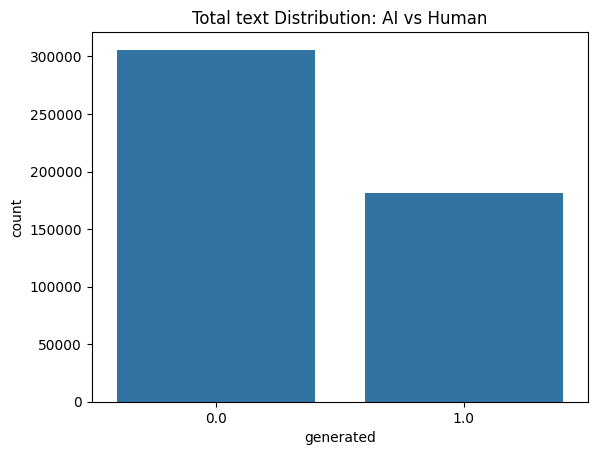

In [23]:
sns.countplot(data=df,x='generated')
plt.title('Total text Distribution: AI vs Human')

In [24]:
print('Total Texts:', df['generated'].count())
print('Human Written Texts:', (df['generated']==0.0).sum())
print('AI Generated Texts:', (df['generated']==1.0).sum())
print(f"Percentage of Human text: {((df['generated']==0.0).sum()/df['generated'].count())*100:.2f} %")
print(f"Percentage of Human text: {((df['generated']==1.0).sum()/df['generated'].count())*100:.2f} %")

Total Texts: 487235
Human Written Texts: 305797
AI Generated Texts: 181438
Percentage of Human text: 62.76 %
Percentage of Human text: 37.24 %


In [25]:
#target_col = 'generated'

#df_sample, _ = train_test_split(df, train_size=0.9, stratify=df[target_col], random_state=42)
#print(f"Sample size: {len(df_sample)}")
#print(df_sample[target_col].value_counts())

#**Text Length Analysis**



In [26]:
df['word_count'] = df['text'].str.count(' ') + 1
df['sentence_count'] = df['text'].str.count(r'[.!?]+').fillna(1)
df['avg_word_len'] = df['text'].str.len() / df['word_count']
df['avg_sent_len'] = df['word_count'] / df['sentence_count']

# KDE plot for word count
Here we used a **KDE** plot to see the probability density of the word count of both human and AI essays.

As we can see that the orange peak is significantly higher and narrower thant the blue peak. Moreover it also proves a hypothesis of one the the research paper we have read that the human generated text contains more burstiness and has the tendency to write more.

Since the  difference is not that much it wont be a good feature but a good data to see.



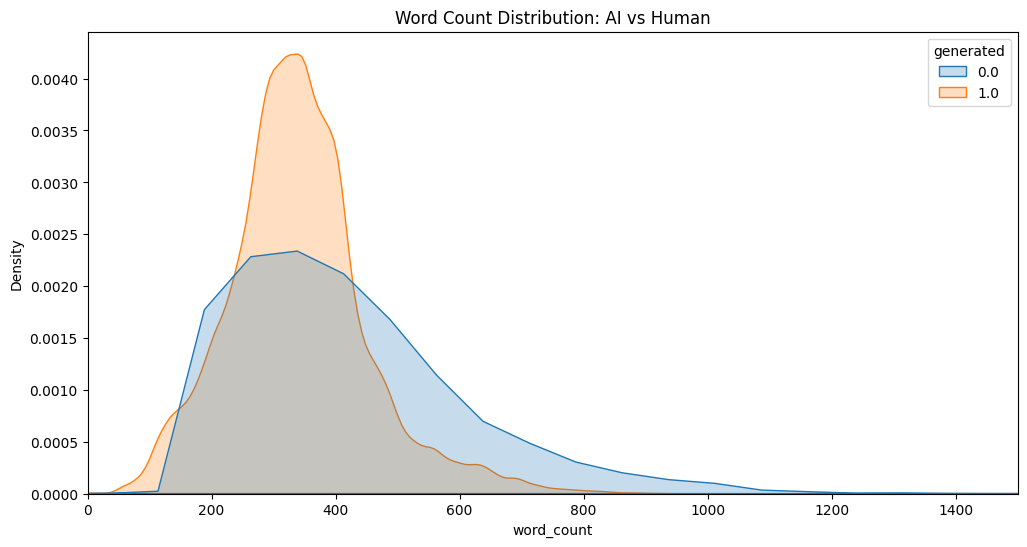

In [27]:
plt.figure(figsize=(12, 6))

sns.kdeplot(data=df, x='word_count', hue='generated', fill=True, palette='tab10', common_norm=False)
plt.xlim(0, 1500)

plt.title('Word Count Distribution: AI vs Human')
plt.ylabel('Density')

plt.show()

# KDE plot for sentence length
As we can see the AI is very consistent with its number of words per sentence whereas the human text has a much higher density of short and long sentences.

This might be a good feature to work with.

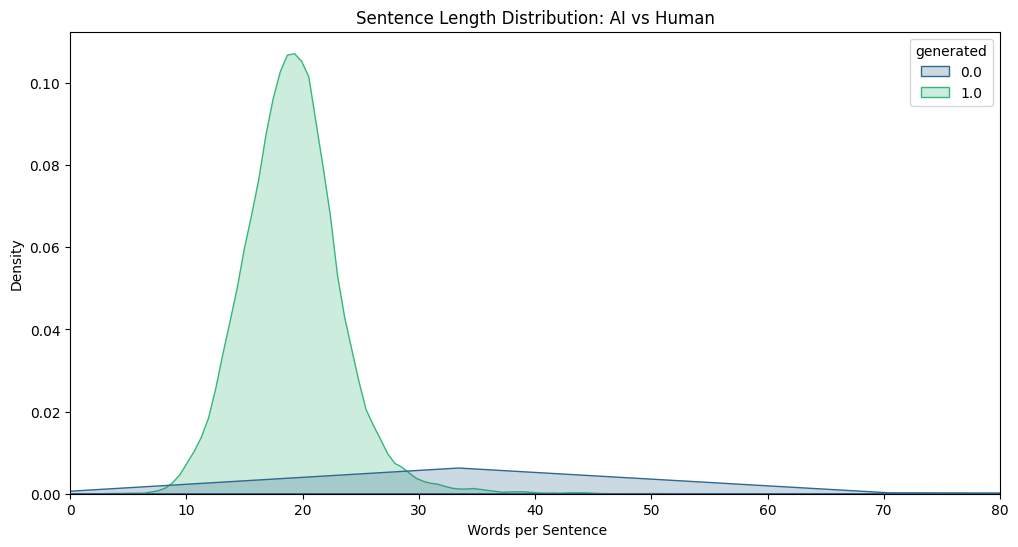

In [28]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='avg_sent_len', hue='generated',
            fill=True, palette='viridis', common_norm=False)
plt.xlim(0, 80)
plt.title('Sentence Length Distribution: AI vs Human')
plt.xlabel(' Words per Sentence')
plt.ylabel('Density')
plt.show()

In [29]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
import string

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mahdi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mahdi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mahdi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mahdi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\mahdi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [30]:
%pip install textstat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
%pip install spacy
!python -m spacy download en_core_web_sm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Feature Engineering
We extract structural and stylistic features from the text using spaCy and our main focus was stylometric. Instead of vectorizing the text, we calculate numerical metrics that capture the writing paterns created by both AI and human texts. The features extracted are:

- **Punctuation Density**: Ratio of punctuation used to total words
- **Stopword Ratio**: Ratio of stopwords to total words as we can see AI tends to use a predictable distribution of functional words
- **Noun/Verb/Adjective Density**: Ratio of each POS tag to total words to see the different density of each pos tags
- **Sentence Length**: Average number of words per sentence
- **Type-Token Ratio (TTR)**: Unique words used per total words as AI tends to have lower lexical diversity
- **FK Grade**: This is the Readability score.
- **Fog Index**: Another readability metric used to penalizing complex words as ai tends to use complex words
- **Burstiness**: Standard deviation of sentence lengths as we have previously seen humans have varying sentence lengths
- **Entropy**: Measures the unpredictability of word choices.
- **Avg Word Length**: Average number of characters per word

In [32]:
import spacy
from tqdm import tqdm
import numpy as np
import textstat
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp.add_pipe("sentencizer")

texts = df['text'].tolist()
records = []

for doc in tqdm(nlp.pipe(texts, batch_size=500 , n_process=1), total=len(texts)):
    word_count = max(1, len(doc))
    sentences = list(doc.sents)
    sent_lengths = [len(sent) for sent in sentences]

    punc_density = sum(t.is_punct for t in doc) / word_count
    stopword = sum(t.is_stop for t in doc) / word_count
    noun_density = sum(t.pos_ == 'NOUN' for t in doc) / word_count
    verb_density = sum(t.pos_ == 'VERB' for t in doc) / word_count
    adj_density = sum(t.pos_ == 'ADJ' for t in doc) / word_count
    sent_length = word_count / max(1, len(sentences))

    words = [t.text.lower() for t in doc if not t.is_punct and not t.is_space]

    ttr = len(set(words)) / max(1, len(words))

    fk_grade = textstat.flesch_kincaid_grade(doc.text)
    fog_index = textstat.gunning_fog(doc.text)

    burstiness = np.std(sent_lengths) if len(sent_lengths) > 1 else 0

    word_freq = Counter(words)
    total = sum(word_freq.values())
    probs = [c / total for c in word_freq.values()]
    entropy = -sum(p * np.log2(p) for p in probs if p > 0)

    records.append({
        'punctuation density': punc_density,
        'stopword': stopword,
        'noun density': noun_density,
        'verb density': verb_density,
        'adj density': adj_density,
        'sentence length': sent_length,
        'ttr': ttr,
        'fk_grade': fk_grade,
        'fog_index': fog_index,
        'burstiness': burstiness,
        'entropy': entropy
    })

feature_df = pd.DataFrame(records, index=df.index)
new_df = df.copy()
new_df[feature_df.columns] = feature_df

print(new_df.head())

100%|██████████| 487235/487235 [5:42:09<00:00, 23.73it/s]    


                                                text  generated  word_count  \
0  Cars. Cars have been around since they became ...        0.0         581   
1  Transportation is a large necessity in most co...        0.0         458   
2  "America's love affair with it's vehicles seem...        0.0         740   
3  How often do you ride in a car? Do you drive a...        0.0         684   
4  Cars are a wonderful thing. They are perhaps o...        0.0         868   

   sentence_count  avg_word_len  avg_sent_len  punctuation density  stopword  \
0              24      5.660929     24.208333             0.104545  0.443939   
1              27      5.978166     16.962963             0.115094  0.450943   
2              48      5.983784     15.416667             0.109929  0.468085   
3              51      5.866959     13.411765             0.133663  0.466584   
4              51      5.412442     17.019608             0.105641  0.484103   

   noun density  verb density  adj density  

In [33]:
new_df.to_csv('new_df_features.csv', index=False)
print("Saved!")

Saved!


In [34]:
feature_cols = ['punctuation density', 'stopword', 'noun density', 'verb density',
                'adj density', 'sentence length', 'ttr', 'fk_grade',
                'fog_index', 'burstiness', 'entropy']

new_df.groupby('generated')[feature_cols].mean()

,punctuation density,stopword,noun density,verb density,adj density,sentence length,ttr,fk_grade,fog_index,burstiness,entropy
generated,,,,,,,,,,,
0.0,0.087433,0.514046,0.182654,0.116468,0.061588,24.161170,0.436982,9.876933,12.120101,10.948733,6.747852
1.0,0.106108,0.441238,0.211669,0.114605,0.082672,21.898164,0.472188,11.503956,14.162898,7.438826,6.653283


## Exploratory Data Analysis for feature engineering
Here we compare the distribution of each feature between AI and Human generated text using boxplots. Features where the boxes don't overlap much are the most useful for classification such as burstiness entropy and such.

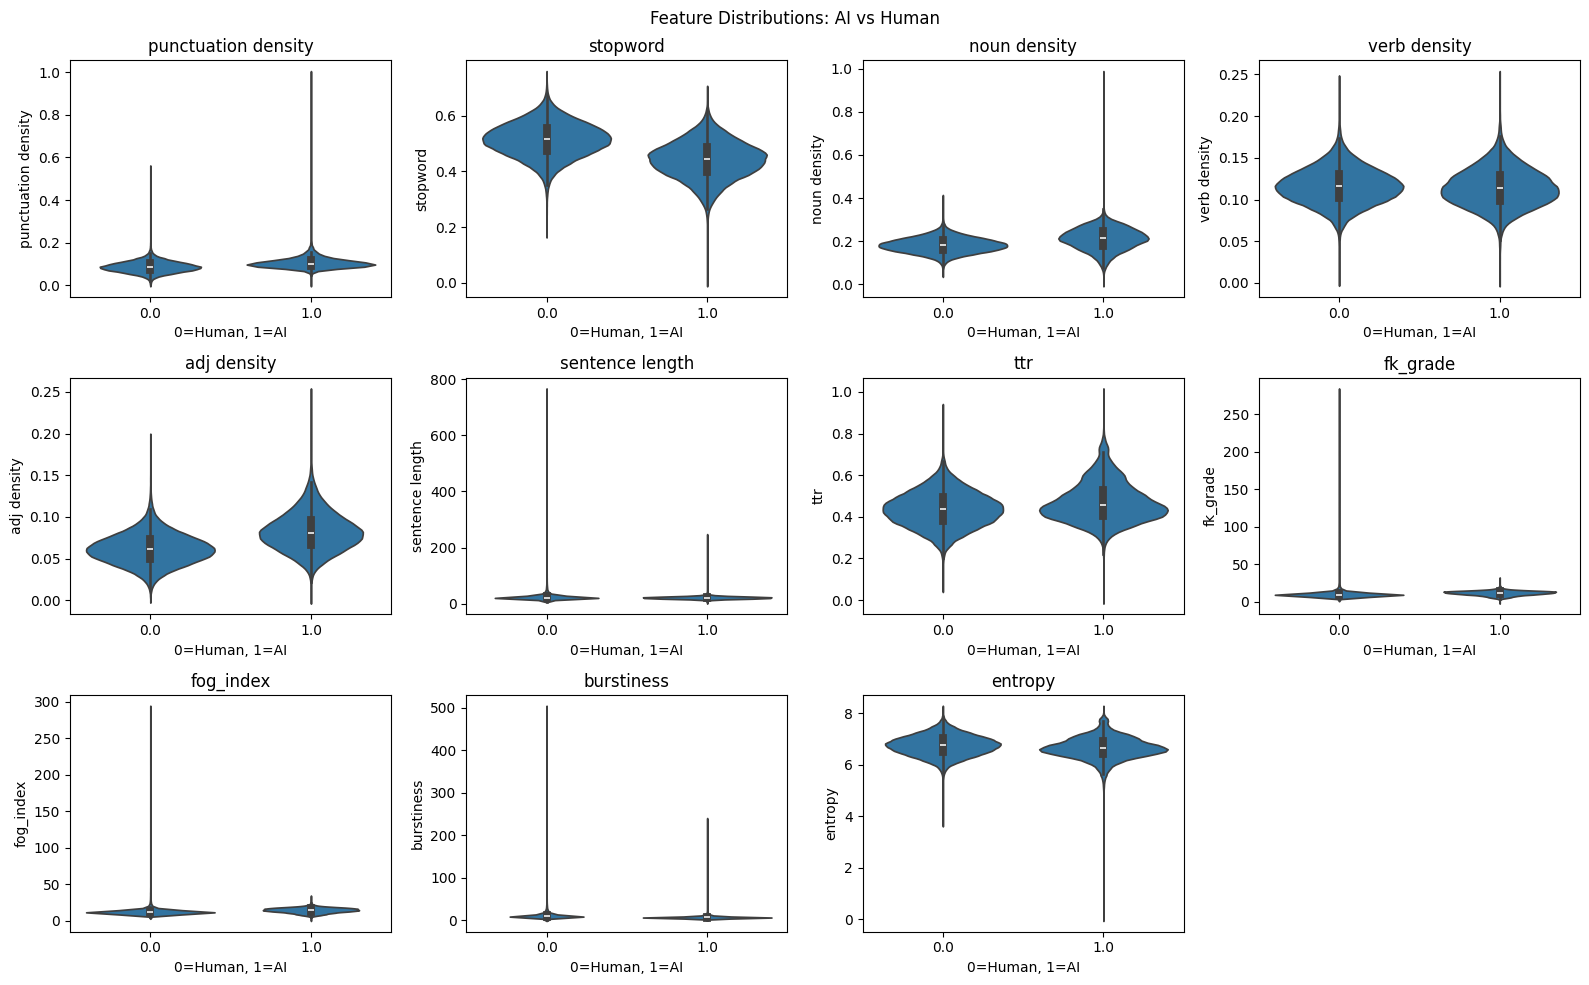

In [35]:
import seaborn as sns

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.violinplot(x='generated', y=col, data=new_df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('0=Human, 1=AI')

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions: AI vs Human')
plt.tight_layout()
plt.show()

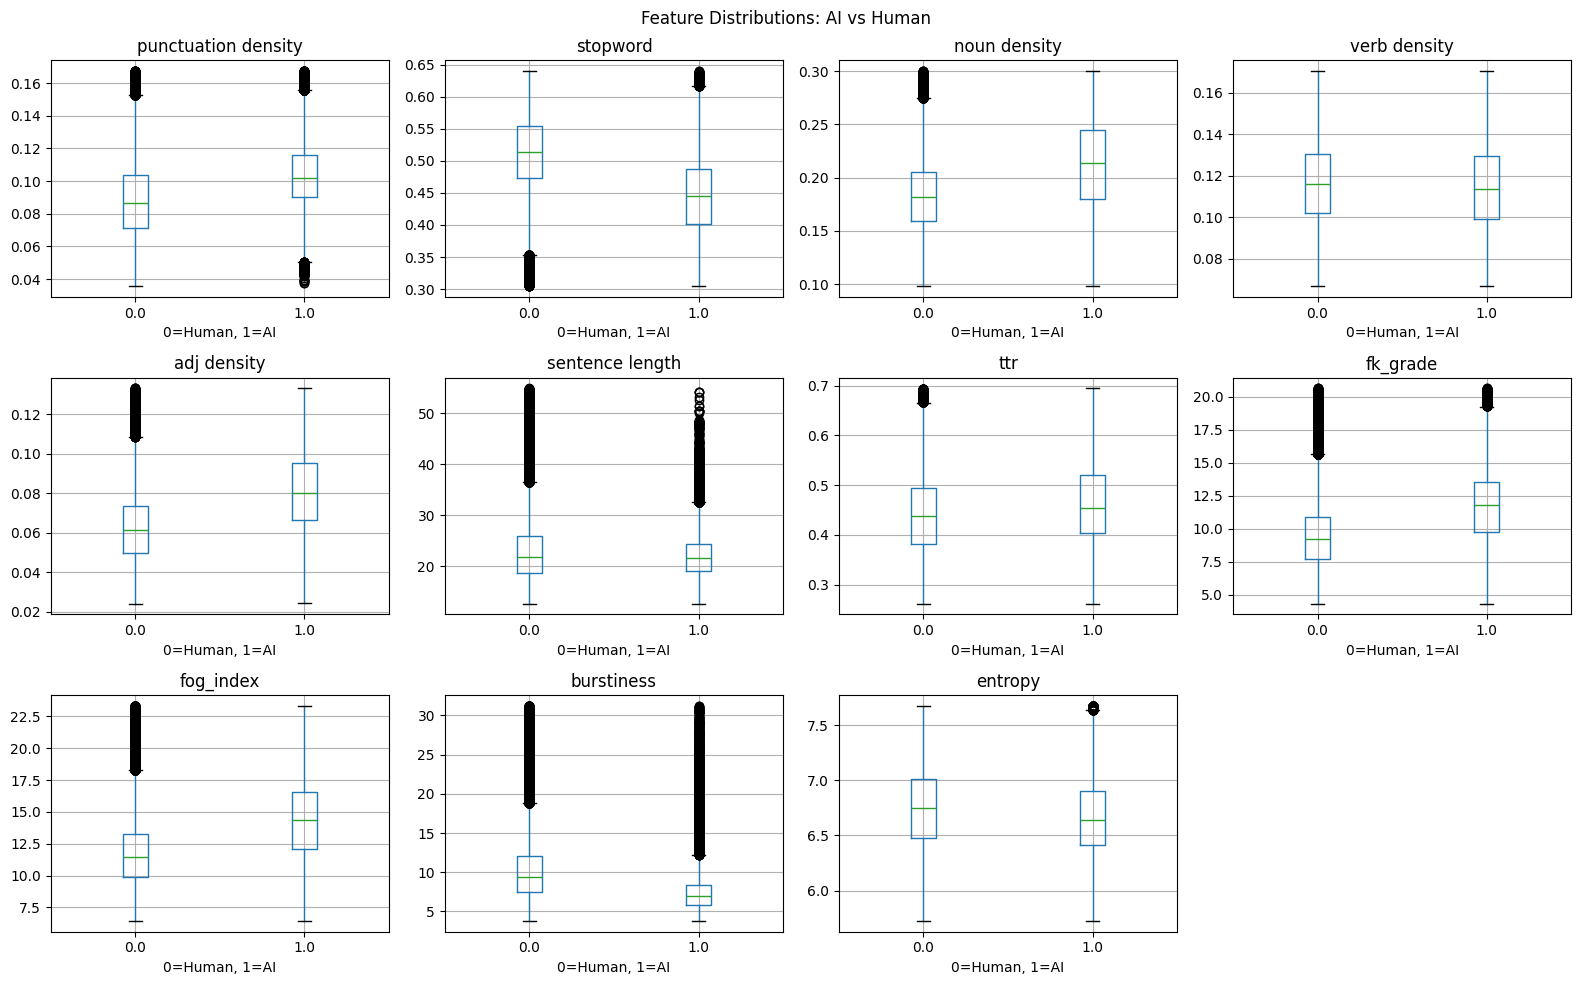

In [36]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    q_low = new_df[col].quantile(0.01)
    q_high = new_df[col].quantile(0.99)
    filtered = new_df[(new_df[col] >= q_low) & (new_df[col] <= q_high)]
    filtered.boxplot(column=col, by='generated', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('0=Human, 1=AI')

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions: AI vs Human')
plt.tight_layout()
plt.show()

## Data Preparation
We prepare the data for model training by:
1. checking for null values
2. Selecting the 12 features as input and 'generated' as the target y
3. Splitting into 80% training and 20% testing sets
4. Scaling features using StandardScaler so no single feature dominates

In [37]:
print(df.isnull().sum())

text              0
generated         0
word_count        0
sentence_count    0
avg_word_len      0
avg_sent_len      0
dtype: int64


In [38]:
print(new_df.info())


<class 'pandas.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   text                 487235 non-null  str    
 1   generated            487235 non-null  float64
 2   word_count           487235 non-null  int64  
 3   sentence_count       487235 non-null  int64  
 4   avg_word_len         487235 non-null  float64
 5   avg_sent_len         487235 non-null  float64
 6   punctuation density  487235 non-null  float64
 7   stopword             487235 non-null  float64
 8   noun density         487235 non-null  float64
 9   verb density         487235 non-null  float64
 10  adj density          487235 non-null  float64
 11  sentence length      487235 non-null  float64
 12  ttr                  487235 non-null  float64
 13  fk_grade             487235 non-null  float64
 14  fog_index            487235 non-null  float64
 15  burstiness           487235 

In [39]:
feature_cols = ['punctuation density', 'stopword', 'noun density', 'verb density',
                'adj density', 'sentence length', 'ttr', 'fk_grade',
                'fog_index','burstiness', 'entropy', 'avg_word_len']
X = new_df[feature_cols]
y = new_df['generated']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training size: {len(X_train)}")
print(f"Testing size: {len(X_test)}")

Training size: 389788
Testing size: 97447


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

lr = LogisticRegression()
lr.fit(X_train, y_train)
print("Logistic Regression:")
print(classification_report(y_test, lr.predict(X_test)))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest:")
print(classification_report(y_test, rf.predict(X_test)))

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting:")
print(classification_report(y_test, gb.predict(X_test)))

Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.90     61159
         1.0       0.84      0.80      0.82     36288

    accuracy                           0.87     97447
   macro avg       0.86      0.85      0.86     97447
weighted avg       0.87      0.87      0.87     97447

Random Forest:
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     61159
         1.0       0.99      0.97      0.98     36288

    accuracy                           0.98     97447
   macro avg       0.99      0.98      0.98     97447
weighted avg       0.98      0.98      0.98     97447

Gradient Boosting:
              precision    recall  f1-score   support

         0.0       0.91      0.94      0.93     61159
         1.0       0.90      0.84      0.87     36288

    accuracy                           0.91     97447
   macro avg       0.90      0.89      0.90     97447
weighted avg       

In [43]:
from sklearn.svm import LinearSVC
import time

print("Training SVM...")
start = time.time()
svm = LinearSVC(random_state=42, max_iter=2000)
svm.fit(X_train, y_train)
print(classification_report(y_test, svm.predict(X_test)))
from xgboost import XGBClassifier

print("Training XGBoost...")
start = time.time()
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
print(classification_report(y_test, xgb.predict(X_test)))

from sklearn.ensemble import VotingClassifier

print("Training Ensemble...")
start = time.time()
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('gb', gb), ('svm', svm), ('xgb', xgb)],
    voting='hard'
)
ensemble.fit(X_train, y_train)
print(classification_report(y_test, ensemble.predict(X_test)))

Training SVM...
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89     61159
         1.0       0.84      0.79      0.81     36288

    accuracy                           0.87     97447
   macro avg       0.86      0.85      0.85     97447
weighted avg       0.86      0.87      0.87     97447

Training XGBoost...
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96     61159
         1.0       0.94      0.91      0.93     36288

    accuracy                           0.94     97447
   macro avg       0.94      0.94      0.94     97447
weighted avg       0.94      0.94      0.94     97447

Training Ensemble...
              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94     61159
         1.0       0.92      0.88      0.90     36288

    accuracy                           0.93     97447
   macro avg       0.92      0.92      0.92     97447
weighted avg     

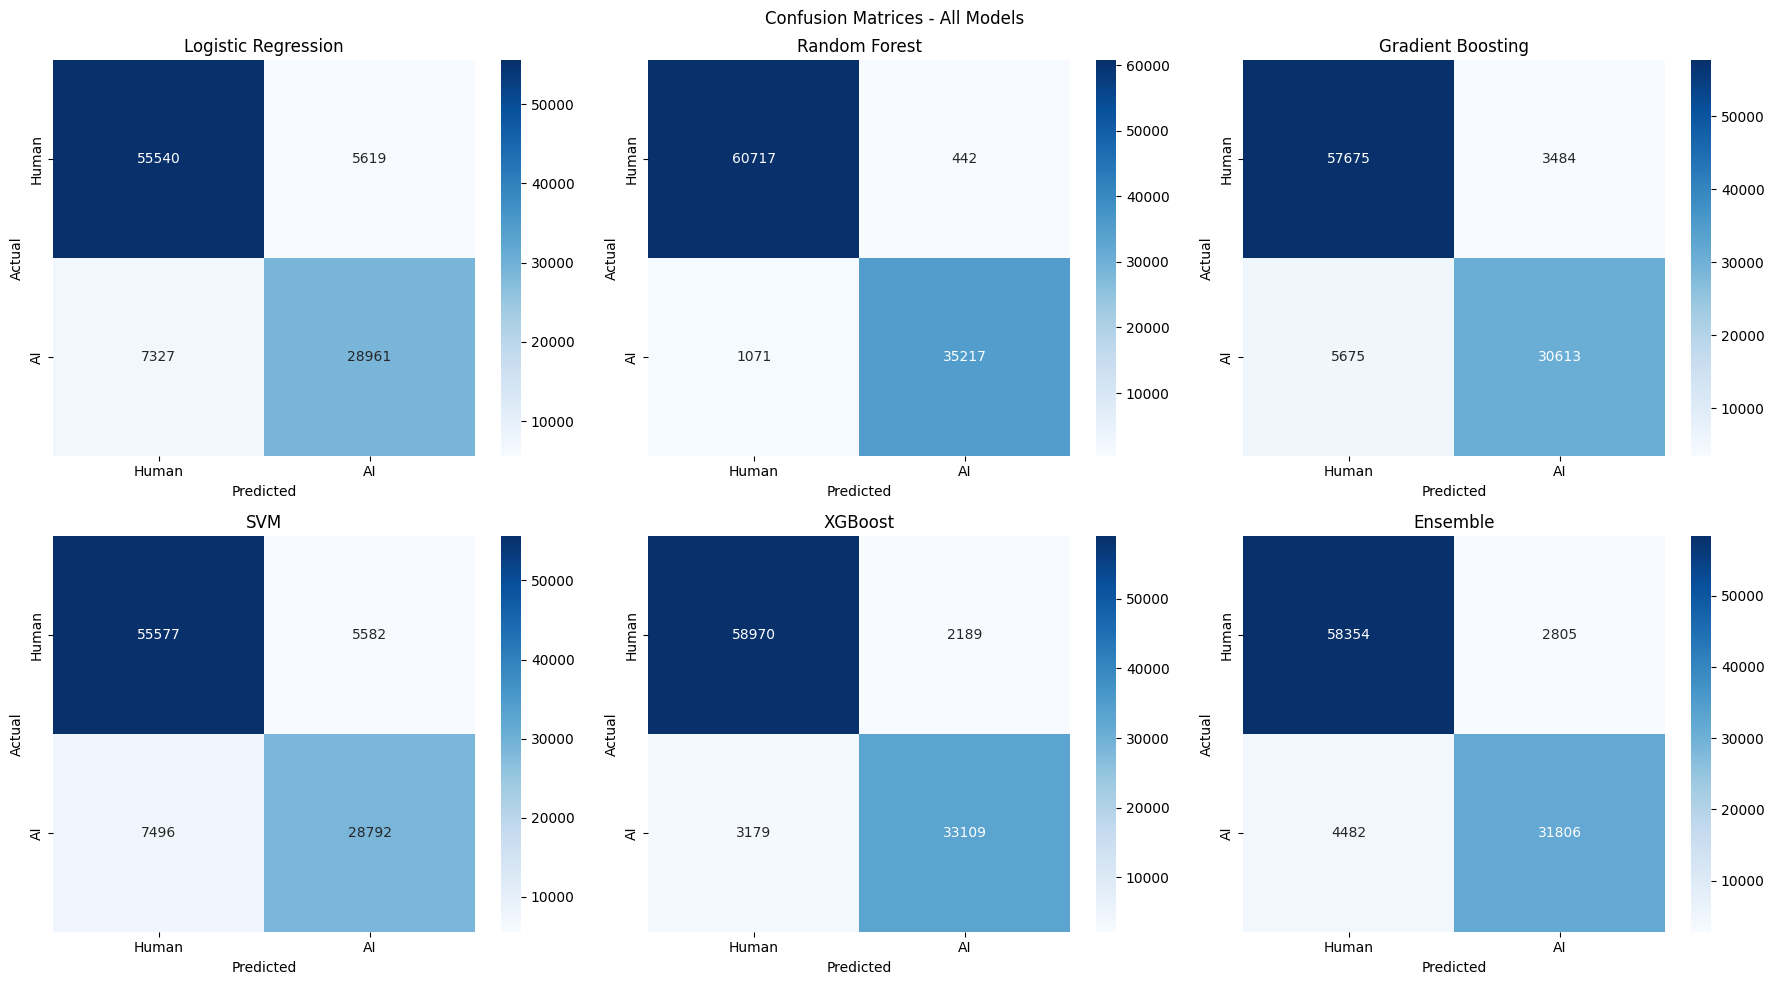

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

models = [('Logistic Regression', lr), ('Random Forest', rf), ('Gradient Boosting', gb),
          ('SVM', svm), ('XGBoost', xgb), ('Ensemble', ensemble)]

for ax, (name, model) in zip(axes, models):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Models')
plt.tight_layout()
plt.show()

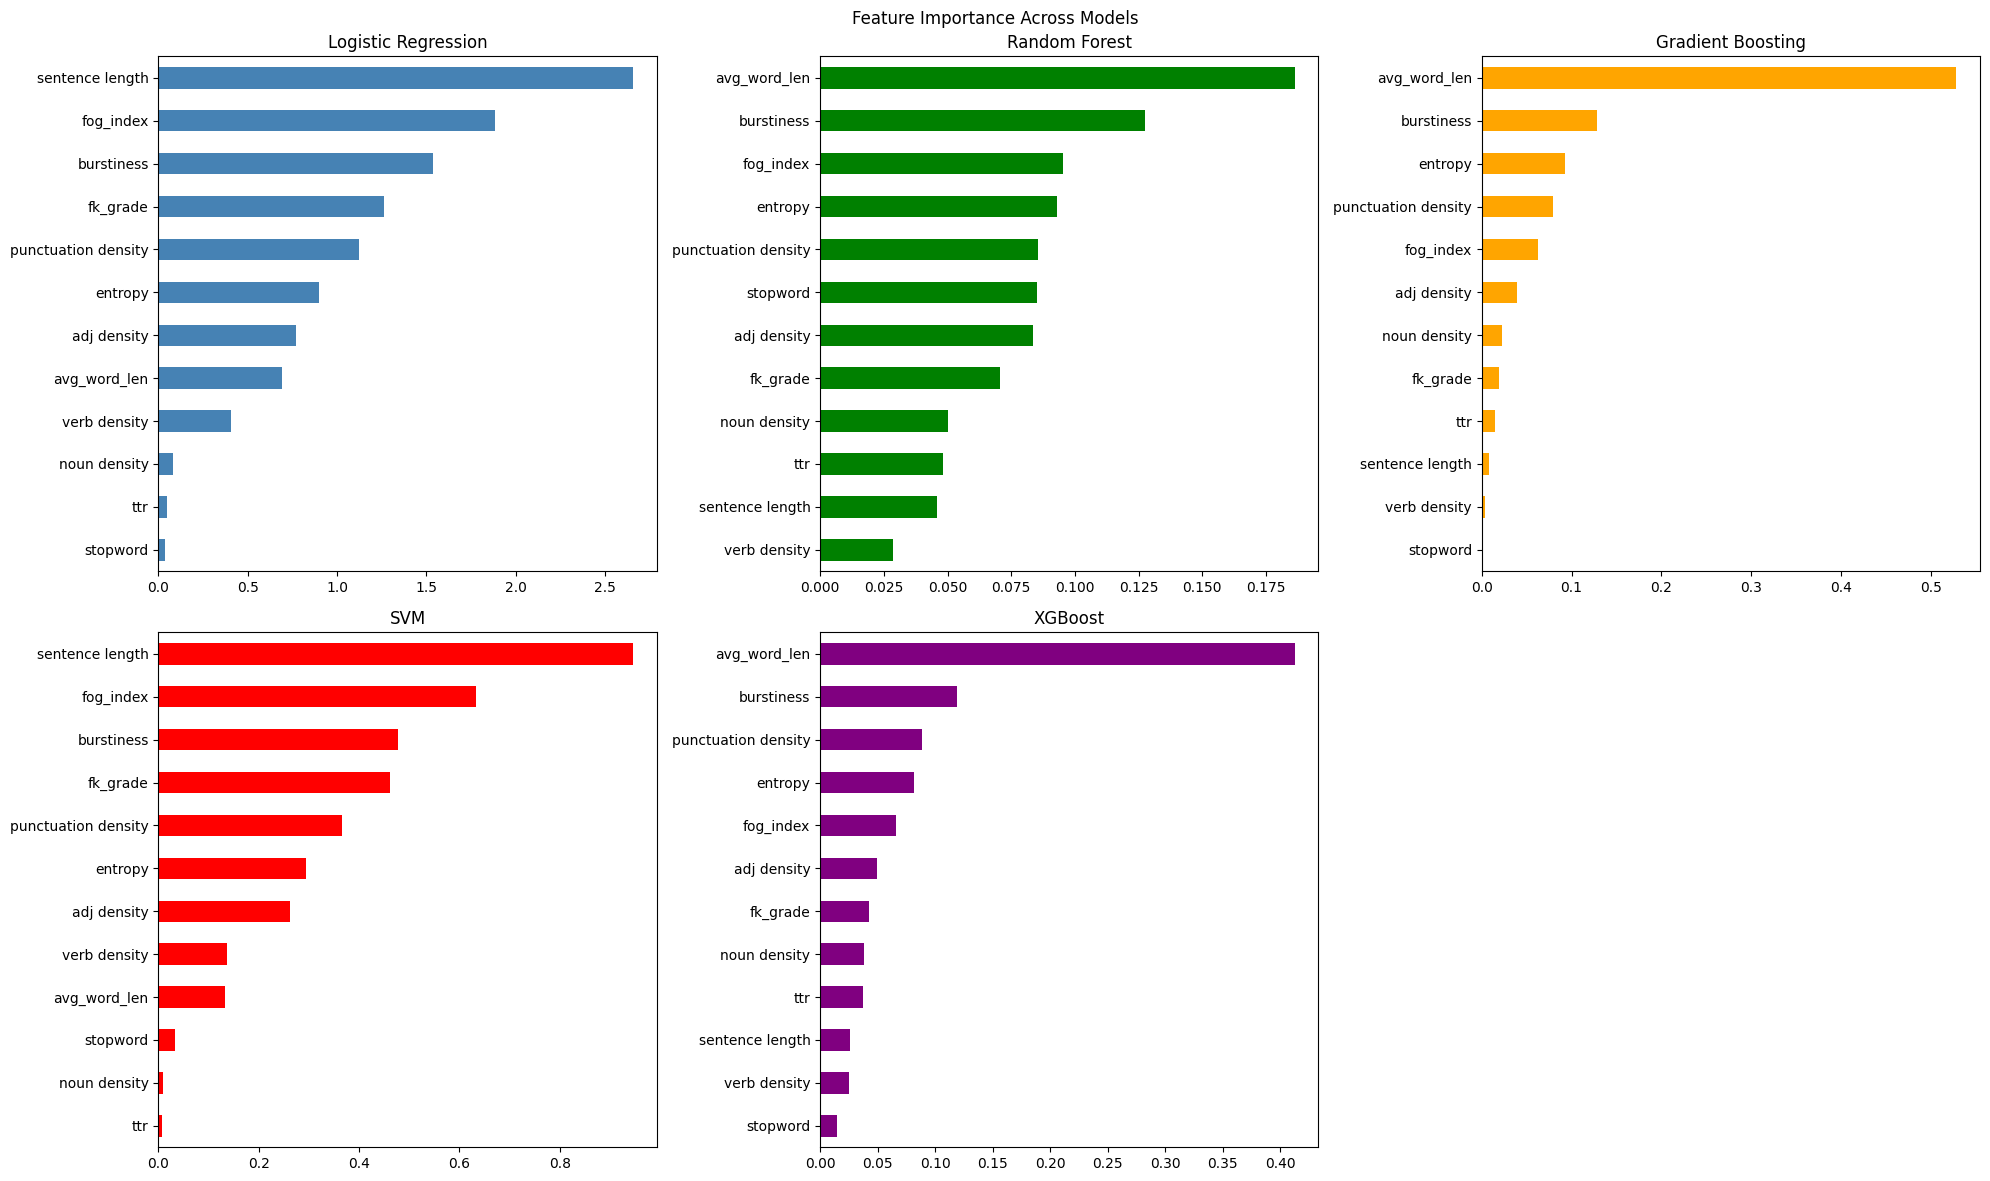

In [45]:
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

gb_importance = pd.Series(gb.feature_importances_, index=feature_cols).sort_values(ascending=True)

lr_importance = pd.Series(np.abs(lr.coef_[0]), index=feature_cols).sort_values(ascending=True)

svm_importance = pd.Series(np.abs(svm.coef_[0]), index=feature_cols).sort_values(ascending=True)

xgb_importance = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

lr_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic Regression')

rf_importance.plot(kind='barh', ax=axes[1], color='green')
axes[1].set_title('Random Forest')

gb_importance.plot(kind='barh', ax=axes[2], color='orange')
axes[2].set_title('Gradient Boosting')

svm_importance.plot(kind='barh', ax=axes[3], color='red')
axes[3].set_title('SVM')

xgb_importance.plot(kind='barh', ax=axes[4], color='purple')
axes[4].set_title('XGBoost')

axes[5].set_visible(False)

plt.suptitle('Feature Importance Across Models')
plt.tight_layout()
plt.show()

In [47]:
feature_cols_new = ['punctuation density', 'adj density', 'sentence length',
                        'fk_grade', 'fog_index', 'burstiness', 'entropy', 'avg_word_len']

X_reduced = new_df[feature_cols_new]
y = new_df['generated']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, test_size=0.2, stratify=y, random_state=42)

scaler2 = StandardScaler()
X_train_r = scaler2.fit_transform(X_train_r)
X_test_r = scaler2.transform(X_test_r)

In [48]:
print("Training Logistic Regression...")
lr_r = LogisticRegression()
lr_r.fit(X_train_r, y_train_r)
print(classification_report(y_test_r, lr_r.predict(X_test_r)))

print("Training Random Forest...")
rf_r = RandomForestClassifier(n_estimators=100, random_state=42)
rf_r.fit(X_train_r, y_train_r)
print(classification_report(y_test_r, rf_r.predict(X_test_r)))

print("Training Gradient Boosting...")
gb_r = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_r.fit(X_train_r, y_train_r)
print(classification_report(y_test_r, gb_r.predict(X_test_r)))

print("Training SVM...")
svm_r = LinearSVC(random_state=42, max_iter=2000)
svm_r.fit(X_train_r, y_train_r)
print(classification_report(y_test_r, svm_r.predict(X_test_r)))

print("Training XGBoost...")
xgb_r = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_r.fit(X_train_r, y_train_r)
print(classification_report(y_test_r, xgb_r.predict(X_test_r)))

print("Training Ensemble...")
ensemble_r = VotingClassifier(
    estimators=[('lr', lr_r), ('rf', rf_r), ('gb', gb_r), ('svm', svm_r), ('xgb', xgb_r)],
    voting='hard'
)
ensemble_r.fit(X_train_r, y_train_r)
print(classification_report(y_test_r, ensemble_r.predict(X_test_r)))

Training Logistic Regression...
              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89     61159
         1.0       0.83      0.79      0.81     36288

    accuracy                           0.86     97447
   macro avg       0.86      0.85      0.85     97447
weighted avg       0.86      0.86      0.86     97447

Training Random Forest...
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     61159
         1.0       0.98      0.97      0.98     36288

    accuracy                           0.98     97447
   macro avg       0.98      0.98      0.98     97447
weighted avg       0.98      0.98      0.98     97447

Training Gradient Boosting...
              precision    recall  f1-score   support

         0.0       0.91      0.94      0.92     61159
         1.0       0.89      0.84      0.86     36288

    accuracy                           0.90     97447
   macro avg       0.90      0.89      0

In [49]:
print("Overfitting Check - Train vs Test Accuracy")

models_all = [
    ('Logistic Regression', lr),
    ('Random Forest', rf),
    ('Gradient Boosting', gb),
    ('SVM', svm),
    ('XGBoost', xgb),
    ('Ensemble', ensemble)
]

for name, model in models_all:
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc
    status = "OVERFIT" if gap > 0.02 else "OK"
    print(f"{name:25} Train: {train_acc:.3f}  Test: {test_acc:.3f}  Gap: {gap:.3f}  {status}")

Overfitting Check - Train vs Test Accuracy
Logistic Regression       Train: 0.868  Test: 0.867  Gap: 0.001  OK
Random Forest             Train: 1.000  Test: 0.984  Gap: 0.016  OK
Gradient Boosting         Train: 0.908  Test: 0.906  Gap: 0.002  OK
SVM                       Train: 0.867  Test: 0.866  Gap: 0.001  OK
XGBoost                   Train: 0.952  Test: 0.945  Gap: 0.007  OK
Ensemble                  Train: 0.929  Test: 0.925  Gap: 0.004  OK


In [50]:
print("Training Gradient Boosting (Regularized)")
gb_reg = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='sqrt',
    subsample=0.8,
    learning_rate=0.1,
    random_state=42
)
gb_reg.fit(X_train, y_train)
print(classification_report(y_test, gb_reg.predict(X_test)))

print("Training XGBoost (Regularized)")
xgb_reg = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss'
)
xgb_reg.fit(X_train, y_train)
print(classification_report(y_test, xgb_reg.predict(X_test)))

Training Gradient Boosting (Regularized)
              precision    recall  f1-score   support

         0.0       0.91      0.94      0.92     61159
         1.0       0.90      0.84      0.87     36288

    accuracy                           0.90     97447
   macro avg       0.90      0.89      0.90     97447
weighted avg       0.90      0.90      0.90     97447

Training XGBoost (Regularized)
              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93     61159
         1.0       0.90      0.87      0.88     36288

    accuracy                           0.92     97447
   macro avg       0.91      0.91      0.91     97447
weighted avg       0.92      0.92      0.92     97447



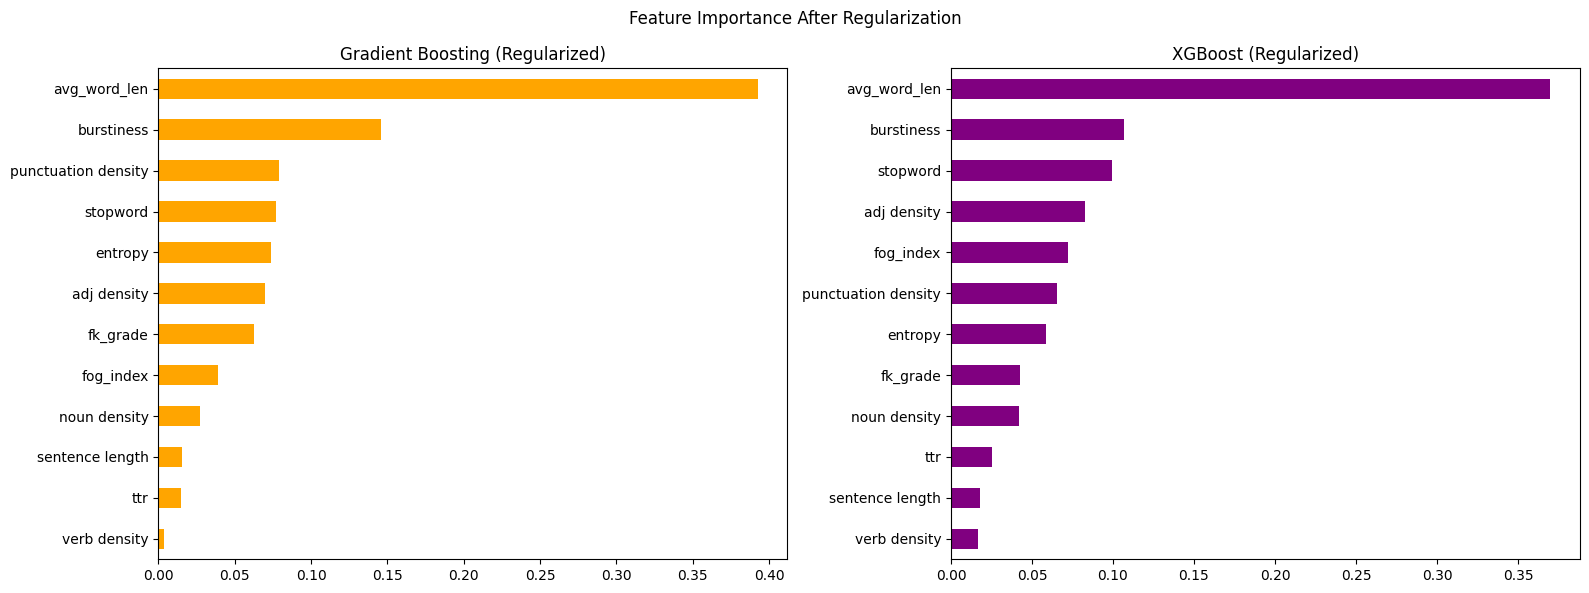

In [51]:
gb_reg_importance = pd.Series(gb_reg.feature_importances_, index=feature_cols).sort_values(ascending=True)
xgb_reg_importance = pd.Series(xgb_reg.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gb_reg_importance.plot(kind='barh', ax=axes[0], color='orange')
axes[0].set_title('Gradient Boosting (Regularized)')

xgb_reg_importance.plot(kind='barh', ax=axes[1], color='purple')
axes[1].set_title('XGBoost (Regularized)')

plt.suptitle('Feature Importance After Regularization')
plt.tight_layout()
plt.show()